In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm


In [11]:
pwd 

'/ewsc/exxact04/vshir/tcga'

In [3]:
labelled_data = pd.read_pickle('pkl/GI_cluster50_labelled_all_mar28.pkl') #data containing the cluster labels for each point 

In [4]:
all_slide_ids = pd.read_pickle('pkl/GI_allslide_IDs_02_18_26.pkl') #list of all the slide IDs 

In [5]:
cancer_types = ['paad','coad','esca','stad','read']

In [6]:
labelled_data.head()

label     X      Y
paad TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC89... 0     0  1792  11264
                                                        1     0  1792  11520
                                                        2    46  2048   9984
                                                        3    46  2048  10240
                                                        4    46  2048  10496

In [23]:
labelled_data.index.set_names(['cancer_type', 'tcga_id', 'number'], inplace=True)
labelled_data = labelled_data[labelled_data.index.get_level_values('cancer_type') != 'luad']

In [17]:
# 1. Convert the MultiIndex to a DataFrame of just the index levels
index_df = labelled_data.index.to_frame(index=False)[['cancer_type', 'tcga_id']]
index_df = index_df[index_df['cancer_type']!='luad']
# 2. Drop duplicates so you have exactly one row per slide
unique_slides = index_df.drop_duplicates()

# 3. Count how many slides belong to each cancer type
cancer_type_counts = unique_slides['cancer_type'].value_counts()

cancer_type_counts

cancer_type
stad    398
coad    396
paad    209
read    158
esca    150
Name: count, dtype: int64

In [25]:
label_counts = labelled_data.groupby('tcga_id')['label'].value_counts().unstack(fill_value=0)
all_labels = list(range(50))
label_counts = label_counts.reindex(columns=all_labels, fill_value=0)

In [27]:
label_counts['total'] = label_counts.loc[:, 0:49].sum(axis=1)

In [28]:
label_counts.head()

label,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,total
tcga_id,,,,,,,,,,,,,,,,,,,,,
TCGA-2H-A9GF-01Z-00-DX1.FA1016AF-3FE3-45DC-A77B-F1ACC2B33B2A,51,116,1577,0,0,32,3485,16,1,259,...,26309,6627,22,587,0,2806,3975,17179,852,111126
TCGA-2H-A9GG-01Z-00-DX1.0C979026-128C-4124-96CB-0B93FF35CFFF,59,68,9,0,0,1,361,96,1,3099,...,1199,2642,8275,133,0,1013,8740,9961,0,70962
TCGA-2H-A9GH-01Z-00-DX1.B2BF80D6-D348-4C5F-A205-6827684BF3B6,48,2,16,1,1,0,30,152,0,3559,...,490,37,84,76,1,980,4105,9413,1473,38161
TCGA-2H-A9GI-01Z-00-DX1.02AA1DD3-2082-4B82-B396-957A127D8278,71,58,45,0,0,0,133,4,0,19826,...,365,519,6,108,0,1724,366,7354,749,75217
TCGA-2H-A9GJ-01Z-00-DX1.F6CC7FC9-85DB-4791-B367-312F1AA3CDA2,34,0,2,0,0,0,118,15,0,2096,...,5,373,4,64,0,2220,8728,28492,244,76903


In [29]:
label_counts['total'].mean() 

np.float64(44836.272311212815)

In [17]:
#Function for one slide
from itertools import combinations

# 1. Map Coordinates to Labels
coord_label_map = dict(zip(zip(sample_df['X'], sample_df['Y']), sample_df['label']))

# 2. Setup
stride = 256
offsets = [
    (stride, 0), (-stride, 0), (0, stride), (0, -stride),
    (stride, stride), (-stride, -stride), (stride, -stride), (-stride, stride)
]

num_clusters = 50
contact_matrix = np.zeros((num_clusters, num_clusters), dtype=int)

# 3. Iterate through all coordinates
for (x, y), label_center in coord_label_map.items():
    for dx, dy in offsets:
        neighbor_coord = (x + dx, y + dy)
        
        if neighbor_coord in coord_label_map:
            label_neighbor = coord_label_map[neighbor_coord]
            contact_matrix[label_center, label_neighbor] += 1 

# 4. Compile Results for unique pairs only (1,225 rows)
results = []
cluster_totals = sample_df['label'].value_counts().reindex(range(num_clusters), fill_value=0)  

# itertools.combinations(range(50), 2) gives exactly 1,225 pairs
for c1, c2 in combinations(range(num_clusters), 2):
    contact_count = contact_matrix[c1, c2] 
    c1_total_points = contact_matrix[c1, :].sum() 
    
    results.append({
        'cluster 1': c1,
        'cluster 2': c2,
        'contact count': contact_count,
        'total cluster 1': sample_df['label'].value_counts()[c1],
        'total cluster 2': sample_df['label'].value_counts()[c2],
        'total cluster 1 interactions': c1_total_points,
        'frequency': contact_count / c1_total_points if c1_total_points > 0 else 0
    })

contact_df = pd.DataFrame(results)


In [23]:
ratio = contact_df['total cluster 1 interactions']/contact_df['total cluster 1']
ratio

0       7.841981
1       7.841981
2       7.841981
3       7.841981
4       7.841981
          ...   
1220    7.043840
1221    7.043840
1222    7.896917
1223    7.896917
1224    7.992970
Length: 1225, dtype: float64

In [31]:
noisy_clusters = [0,3,4,7,21,27,34,45,46] #filter out the noisy clusters 
filtered_df = contact_df[(~contact_df['cluster 1'].isin(noisy_clusters)) & (~contact_df['cluster 2'].isin(noisy_clusters))] #remove self interaction and noise 
filtered_df['ratio'] = filtered_df['total cluster 1 interactions']/filtered_df['total cluster 1']
filtered_df

/tmp/ipykernel_2490696/956512842.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['ratio'] = filtered_df['total cluster 1 interactions']/filtered_df['total cluster 1']


,cluster 1,cluster 2,contact count,total cluster 1,total cluster 2,total cluster 1 interactions,frequency,ratio
49,1,2,0,5,291,40,0.000000,8.000000
52,1,5,0,5,12,40,0.000000,8.000000
53,1,6,0,5,2239,40,0.000000,8.000000
55,1,8,0,5,0,40,0.000000,8.000000
56,1,9,0,5,184,40,0.000000,8.000000
...,...,...,...,...,...,...,...,...
1213,44,48,0,21,569,162,0.000000,7.714286
1214,44,49,0,21,6993,162,0.000000,7.714286
1222,47,48,109,4152,569,32788,0.003324,7.896917
1223,47,49,1210,4152,6993,32788,0.036904,7.896917


In [43]:
filtered_df = contact_df[contact_df['contact count']>contact_df['total cluster 1']]
filtered_df.shape

(28, 7)

In [24]:
filtered_df

,cluster 1,cluster 2,contact count,total cluster 1,total cluster 2,total cluster 1 interactions,frequency
59,1,12,23,5,6235,40,0.575000
83,1,36,9,5,4781,40,0.225000
106,2,12,564,291,6235,2327,0.242372
130,2,36,535,291,4781,2327,0.229910
265,5,36,44,12,4781,96,0.458333
276,5,47,13,12,4152,96,0.135417
326,7,12,70,29,6235,231,0.303030
333,7,19,62,29,815,231,0.268398
350,7,36,48,29,4781,231,0.207792
421,9,26,233,184,277,1470,0.158503


In [32]:
from itertools import combinations

# 1. Setup Parameters
cancer_types = ['coad', 'esca', 'paad', 'stad', 'read']
stride = 256
offsets = [(stride, 0), (-stride, 0), (0, stride), (0, -stride),
           (stride, stride), (-stride, -stride), (stride, -stride), (-stride, stride)]

all_results = []
num_clusters = 50

# 2. Outer Progress Bar: Cancer Types
pbar_ct = tqdm(cancer_types, desc="Overall Progress")

for ct in pbar_ct:
    # Slice the main dataframe for the current cancer type
    ct_data = labelled_data.loc[ct]
    slide_ids = ct_data.index.get_level_values('tcga_id').unique()
    
    # Inner Progress Bar: Slides within the current Cancer Type
    pbar_slides = tqdm(slide_ids, desc=f"Processing {ct.upper()}", leave=False)
    
    for sid in pbar_slides:
        # Isolate the specific slide coordinates and labels
        slide_df = ct_data.loc[sid]
        
        # Fast lookup map using a dictionary for O(1) spatial queries
        coord_map = dict(zip(zip(slide_df['X'], slide_df['Y']), slide_df['label']))
        
        # Initialize an adjacency matrix for this specific slide
        contact_matrix = np.zeros((num_clusters, num_clusters), dtype=int)
        
        # 3. Spatial Iteration: Check 8 neighbors for every point
        for (x, y), l_center in coord_map.items():
            for dx, dy in offsets:
                neighbor = (x + dx, y + dy)
                
                # Check if neighbor exists
                if neighbor in coord_map:
                    l_neigh = coord_map[neighbor]
                    contact_matrix[l_center, l_neigh] += 1
        
        # 4. Reference the pre-computed counts for this specific slide
        counts_for_slide = label_counts.loc[sid]
        
        # 5. Calculate Pairwise Metrics
        for c1, c2 in combinations(range(num_clusters), 2):
            contact_count = contact_matrix[c1, c2]
            
            if contact_count > 0:
                # We now use the total interactions as the denominator
                # total_interactions_c1 must be calculated for each c1
                c1_total_neighbors = contact_matrix[c1, :].sum()
                
                all_results.append({
                    'cancer_type': ct,
                    'tcga_id': sid,
                    'cluster 1': c1,
                    'cluster 2': c2,
                    'contact count': contact_count,
                    'total cluster 1': slide_df['label'].value_counts()[c1],
                    'total cluster 2': slide_df['label'].value_counts()[c2], 
                    'total_c1_interactions': c1_total_neighbors,
                    'frequency': contact_count / c1_total_neighbors if c1_total_neighbors > 0 else 0
                })
# 6. Final Data Consolidation
final_contact_df = pd.DataFrame(all_results)

Overall Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Processing COAD:   0%|          | 0/396 [00:00<?, ?it/s]

Processing ESCA:   0%|          | 0/150 [00:00<?, ?it/s]

Processing PAAD:   0%|          | 0/209 [00:00<?, ?it/s]

Processing STAD:   0%|          | 0/398 [00:00<?, ?it/s]

Processing READ:   0%|          | 0/158 [00:00<?, ?it/s]

In [33]:
final_contact_df

,cancer_type,tcga_id,cluster 1,cluster 2,contact count,total cluster 1,total cluster 2,total_c1_interactions,frequency
0,coad,TCGA-AA-3553-01Z-00-DX1.45a24cd4-6eb2-4f20-945...,3,4,8825,4126,3722,30362,0.290659
1,coad,TCGA-AA-3553-01Z-00-DX1.45a24cd4-6eb2-4f20-945...,3,34,543,4126,129,30362,0.017884
2,coad,TCGA-AA-3553-01Z-00-DX1.45a24cd4-6eb2-4f20-945...,4,34,108,3722,129,29409,0.003672
3,coad,TCGA-AA-3695-01Z-00-DX1.be93a101-7b57-4140-bd8...,3,4,16012,7085,13341,54786,0.292264
4,coad,TCGA-AA-3695-01Z-00-DX1.be93a101-7b57-4140-bd8...,3,13,8,7085,1,54786,0.000146
...,...,...,...,...,...,...,...,...,...
279948,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,44,46,25,571,337,4512,0.005541
279949,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,44,49,2,571,3080,4512,0.000443
279950,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,46,49,30,337,3080,2482,0.012087
279951,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,47,49,3,10,3080,60,0.050000


In [34]:
final_contact_df.to_pickle('pkl/cluster_50_pairwise_slide_04_06_26.pkl')

In [53]:
# 1. Group by cancer type and cluster pair to get contact counts
# We also include 'total cluster 1' and 'total_c1_interactions' in the mean or sum
# depending on how they were calculated per slide.
summary_df = final_contact_df.groupby(['cancer_type', 'cluster 1', 'cluster 2']).agg({
    'contact count': 'sum',
    'total cluster 1': 'sum',
    'total_c1_interactions': 'sum'
}).reset_index()

# 2. Recalculate Frequency
# Frequency = (Total Contacts between C1 and C2) / (Total Interactions C1 had overall)
summary_df['frequency'] = summary_df['contact count'] / summary_df['total_c1_interactions']

# 3. Optional: Calculate the "Global Ratio" to see if it approaches 8
# summary_df['global_ratio'] = summary_df['total_c1_interactions'] / summary_df['total cluster 1']

summary_df = summary_df.sort_values(['cancer_type', 'cluster 1', 'cluster 2'])

In [54]:
summary_df

,cancer_type,cluster 1,cluster 2,contact count,total cluster 1,total_c1_interactions,frequency
0,coad,0,1,77,239810,1871860,0.000041
1,coad,0,2,3480,612543,4738758,0.000734
2,coad,0,3,58,48398,370757,0.000156
3,coad,0,4,16,1003,6726,0.002379
4,coad,0,5,554,282791,2190947,0.000253
...,...,...,...,...,...,...,...
5814,stad,46,48,23826,326760,2409259,0.009889
5815,stad,46,49,27181,452970,3323591,0.008178
5816,stad,47,48,12384,85161,647334,0.019131
5817,stad,47,49,5744,143759,1106262,0.005192


In [55]:
summary_df.to_pickle('pkl/cluster_50_pairwise_summary_04_06_26.pkl')

In [12]:
summary_df = pd.read_pickle('pkl/cluster_50_pairwise_summary_04_06_26.pkl') 

In [13]:
noisy_clusters = [0,3,4,7,21,27,34,45,46] #filter out the noisy clusters 
filtered_summary_df = summary_df[(~summary_df['cluster 1'].isin(noisy_clusters)) & (~summary_df['cluster 2'].isin(noisy_clusters))] #remove self interaction and noise 
filtered_summary_df 

,cancer_type,cluster 1,cluster 2,contact count,total cluster 1,total_c1_interactions,frequency
49,coad,1,2,3739,43957,351321,0.010643
52,coad,1,5,2228,36195,289237,0.007703
53,coad,1,6,4471,35829,286306,0.015616
55,coad,1,8,1612,19618,156871,0.010276
56,coad,1,9,33960,40767,325839,0.104223
...,...,...,...,...,...,...,...
5807,stad,44,48,3816,63961,505297,0.007552
5808,stad,44,49,39,17637,139913,0.000279
5816,stad,47,48,12384,85161,647334,0.019131
5817,stad,47,49,5744,143759,1106262,0.005192


In [26]:
filtered_summary_df['cancer_type'].value_counts() 

cancer_type
stad    818
paad    806
coad    804
esca    787
read    760
Name: count, dtype: int64

In [14]:
filtered_summary_df['global_ratio'] = filtered_summary_df['total_c1_interactions']/filtered_summary_df['total cluster 1'] 

/tmp/ipykernel_1481881/1906798748.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_summary_df['global_ratio'] = filtered_summary_df['total_c1_interactions']/filtered_summary_df['total cluster 1']


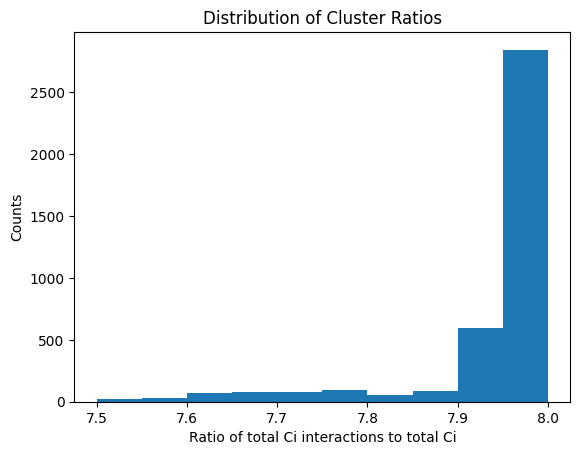

In [18]:
plt.hist(filtered_summary_df['global_ratio'],range=[7.5,8]) 
plt.title('Distribution of Cluster Ratios') 
plt.xlabel('Ratio of total Ci interactions to total Ci') 
plt.ylabel('Counts') 
plt.savefig('png/ratio_histogram.png') 

In [16]:
global_ratio = filtered_summary_df['global_ratio']
(global_ratio>7.9).sum()

np.int64(3438)

In [25]:
(global_ratio>7.95).sum()

np.int64(2844)

In [17]:

((filtered_summary_df['global_ratio'] > 7.5) & (filtered_summary_df['global_ratio'] < 7.9)).sum()

np.int64(505)

In [20]:
filtered_summary_df['global_ratio'].value_counts().sort_index(ascending=False)

global_ratio
8.000000    78
7.999643     1
7.999569     1
7.999549     1
7.999294     1
            ..
6.428571     1
6.250000     1
5.888889     1
5.857143     1
5.500000     1
Name: count, Length: 3877, dtype: int64

In [68]:
final_ratio = final_contact_df['total_c1_interactions']/final_contact_df['total cluster 1']
final_contact_df['ratio'] = final_ratio 
final_contact_df 

,cancer_type,tcga_id,cluster 1,cluster 2,contact count,total cluster 1,total cluster 2,total_c1_interactions,frequency,ratio
0,coad,TCGA-AA-3553-01Z-00-DX1.45a24cd4-6eb2-4f20-945...,3,4,8825,4126,3722,30362,0.290659,7.358701
1,coad,TCGA-AA-3553-01Z-00-DX1.45a24cd4-6eb2-4f20-945...,3,34,543,4126,129,30362,0.017884,7.358701
2,coad,TCGA-AA-3553-01Z-00-DX1.45a24cd4-6eb2-4f20-945...,4,34,108,3722,129,29409,0.003672,7.901397
3,coad,TCGA-AA-3695-01Z-00-DX1.be93a101-7b57-4140-bd8...,3,4,16012,7085,13341,54786,0.292264,7.732675
4,coad,TCGA-AA-3695-01Z-00-DX1.be93a101-7b57-4140-bd8...,3,13,8,7085,1,54786,0.000146,7.732675
...,...,...,...,...,...,...,...,...,...,...
279948,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,44,46,25,571,337,4512,0.005541,7.901926
279949,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,44,49,2,571,3080,4512,0.000443,7.901926
279950,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,46,49,30,337,3080,2482,0.012087,7.364985
279951,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,47,49,3,10,3080,60,0.050000,6.000000


In [69]:
noisy_clusters = [0,3,4,7,21,27,34,45,46] #filter out the noisy clusters 
filtered_df = final_contact_df[(~final_contact_df['cluster 1'].isin(noisy_clusters)) & (~final_contact_df['cluster 2'].isin(noisy_clusters))] #remove self interaction and noise 
filtered_df

,cancer_type,tcga_id,cluster 1,cluster 2,contact count,total cluster 1,total cluster 2,total_c1_interactions,frequency,ratio
13,coad,TCGA-AA-3695-01Z-00-DX1.be93a101-7b57-4140-bd8...,17,36,1,1,1,8,0.125000,8.000000
38,coad,TCGA-D5-6535-01Z-00-DX1.0d7485ff-cf98-4c86-8a6...,1,2,1,20,2098,160,0.006250,8.000000
39,coad,TCGA-D5-6535-01Z-00-DX1.0d7485ff-cf98-4c86-8a6...,1,8,3,20,210,160,0.018750,8.000000
40,coad,TCGA-D5-6535-01Z-00-DX1.0d7485ff-cf98-4c86-8a6...,1,9,49,20,6183,160,0.306250,8.000000
41,coad,TCGA-D5-6535-01Z-00-DX1.0d7485ff-cf98-4c86-8a6...,1,11,1,20,85,160,0.006250,8.000000
...,...,...,...,...,...,...,...,...,...,...
279946,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,42,48,1,136,13,1076,0.000929,7.911765
279947,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,42,49,182,136,3080,1076,0.169145,7.911765
279949,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,44,49,2,571,3080,4512,0.000443,7.901926
279951,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,47,49,3,10,3080,60,0.050000,6.000000


In [76]:
filtered_ratio.shape

(205974,)

In [72]:
filtered_ratio = filtered_df['ratio']

Text(0.5, 1.0, 'Distribution of Ratios Across C1, C2 Pairs in All Slides')

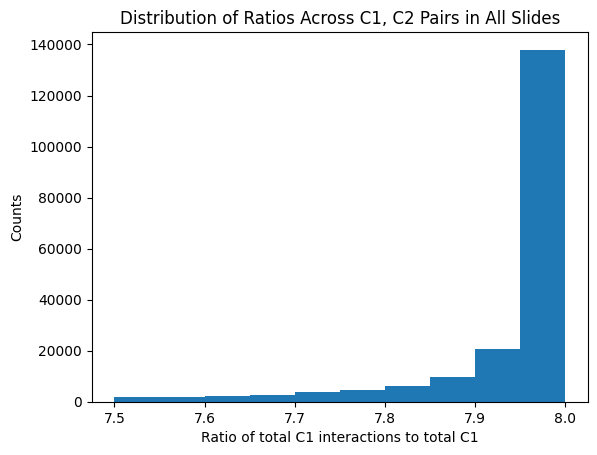

In [82]:
plt.hist(filtered_df['ratio'],range=[7.5,8])
plt.xlabel('Ratio of total C1 interactions to total C1') 
plt.ylabel('Counts') 
plt.title('Distribution of Ratios Across C1, C2 Pairs in All Slides') 

In [79]:
(filtered_ratio==8).sum()

np.int64(50017)

In [74]:
(filtered_ratio>7.9).sum()

np.int64(158343)

In [77]:
(filtered_ratio<7.5).sum()

np.int64(14583)

In [80]:
(filtered_ratio>7.5 and filtered_ratio<7.9).sum()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [73]:
filtered_ratio.value_counts().sort_index(ascending=False)

ratio
8.000000    50017
7.999939       16
7.999907       25
7.999902        8
7.999887       12
            ...  
4.125000        1
4.000000       63
3.500000        2
3.333333        1
3.000000        3
Name: count, Length: 12547, dtype: int64

In [22]:

# 1. Define the boolean condition for 'excess'
is_excess = (final_contact_df['contact count'] > final_contact_df['total cluster 1']) | \
            (final_contact_df['contact count'] > final_contact_df['total cluster 2'])

# 2. Add the boolean result as a temporary column
final_contact_df['is_excess'] = is_excess

# 3. Group by slide and calculate sum (excess) and count (unique rows)
# We use 'agg' to perform multiple calculations at once
diagnostic_df = final_contact_df.groupby(['tcga_id', 'cancer_type'])['is_excess'].agg(
    excess_counts='sum',
    unique_counts='count'
).reset_index()

# 4. Calculate the frequency using the new columns
diagnostic_df['excess_frequency'] = diagnostic_df['excess_counts'] / diagnostic_df['unique_counts']

# 5. Clean up the original dataframe
final_contact_df.drop(columns=['is_excess'], inplace=True)

diagnostic_df

,tcga_id,cancer_type,excess_counts,unique_counts,excess_frequency
0,TCGA-2H-A9GF-01Z-00-DX1.FA1016AF-3FE3-45DC-A77...,esca,64,507,0.126233
1,TCGA-2H-A9GG-01Z-00-DX1.0C979026-128C-4124-96C...,esca,67,340,0.197059
2,TCGA-2H-A9GH-01Z-00-DX1.B2BF80D6-D348-4C5F-A20...,esca,82,352,0.232955
3,TCGA-2H-A9GI-01Z-00-DX1.02AA1DD3-2082-4B82-B39...,esca,54,278,0.194245
4,TCGA-2H-A9GJ-01Z-00-DX1.F6CC7FC9-85DB-4791-B36...,esca,59,229,0.257642
...,...,...,...,...,...
1306,TCGA-Z6-A9VB-01Z-00-DX1.D35A32ED-DFEE-4070-954...,esca,52,189,0.275132
1307,TCGA-Z6-AAPN-01Z-00-DX1.345F7431-CD48-40DB-89D...,esca,69,225,0.306667
1308,TCGA-ZA-A8F6-01Z-00-DX1.89510833-5BC8-4983-817...,stad,71,303,0.234323
1309,TCGA-ZQ-A9CR-01Z-00-DX1.C9AC9991-7054-4068-A7A...,stad,46,155,0.296774


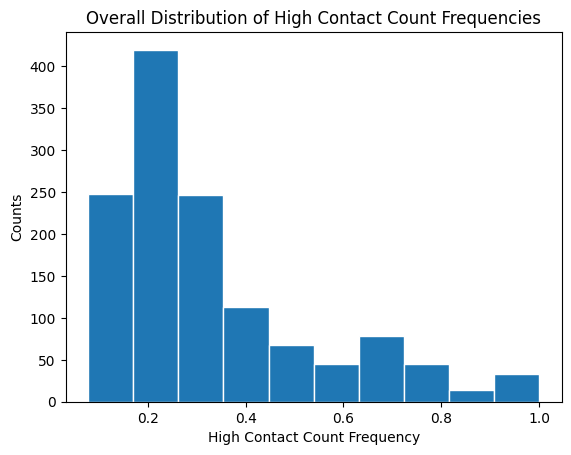

In [32]:
diagnostic_df['excess_frequency'].hist(edgecolor='white')
plt.xlabel('High Contact Count Frequency')
plt.ylabel('Counts') 
plt.title('Overall Distribution of High Contact Count Frequencies') 
plt.grid(False) 
plt.show()

In [27]:
diagnostic_df[diagnostic_df['tcga_id']=='TCGA-G4-6310-01Z-00-DX1.b88472d4-3adc-4e4d-b0f2-0dc195a3d7df']

,tcga_id,cancer_type,excess_counts,unique_counts,excess_frequency
865,TCGA-G4-6310-01Z-00-DX1.b88472d4-3adc-4e4d-b0f...,coad,51,366,0.139344


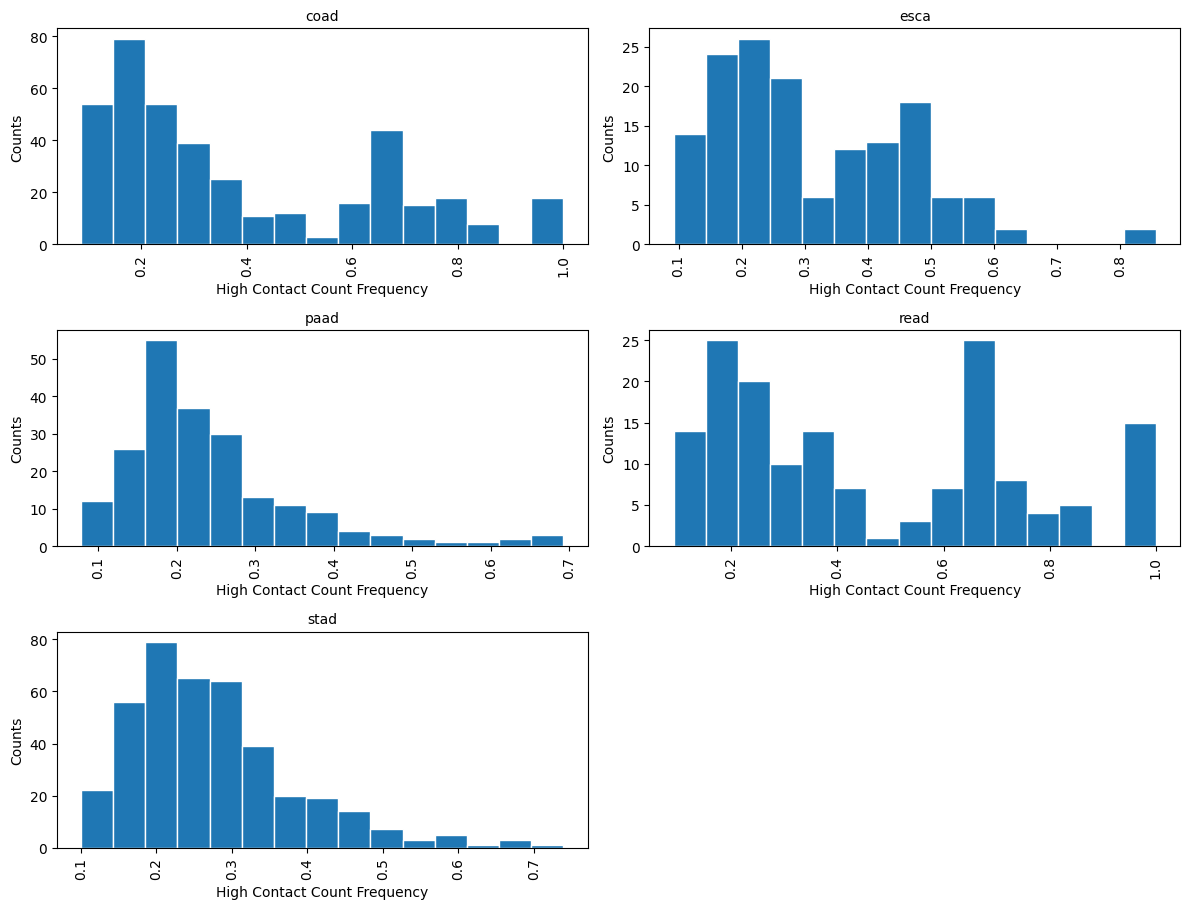

In [34]:
import matplotlib.pyplot as plt

# Using the 'by' parameter creates a subplot for each unique value in cancer_type
axes = diagnostic_df.hist(
    column='excess_frequency', 
    by='cancer_type', 
    figsize=(12, 10),    # Adjust size based on number of cancer types
    bins=15,             # Adjust bins for better granularity
    edgecolor='white',   # Better visual separation of bars
    grid=False           # Removes gridlines automatically
)

# 2. Iterate through the array of axes to set labels
for ax in axes.flatten():  # .flatten() makes it easy to loop even if it's a 2D grid
    ax.set_xlabel('High Contact Count Frequency')
    ax.set_ylabel('Counts')
    
    # Optional: Make titles slightly smaller to avoid crowding
    ax.title.set_size(10)
    
# Improve layout to prevent titles from overlapping axes
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 

plt.show()

In [35]:
# 1. Sum contact counts across all slides for each cancer_type and pair
aggregated_df = final_contact_df.groupby(['cancer_type', 'cluster 1', 'cluster 2'])['contact count'].sum().reset_index()

# 2. Calculate the GLOBAL total interactions for Cluster 1 within each cancer type
# First, get totals where it appears as cluster 1
c1_sums = aggregated_df.groupby(['cancer_type', 'cluster 1'])['contact count'].sum().reset_index()
c1_sums.columns = ['cancer_type', 'cluster 1', 'total c1 interactions']

# 3. Merge this global total back into your summary dataframe
# This ensures every row with (cancer_type, cluster 1) has the exact same denominator
summary_df = aggregated_df.merge(c1_sums, on=['cancer_type', 'cluster 1'])

# 4. Recompute frequency based on global interaction total
summary_df['frequency'] = summary_df['contact count'] / summary_df['total c1 interactions']
summary_df = summary_df.sort_values(['cancer_type', 'cluster 1', 'cluster 2'])

In [36]:
summary_df

,cancer_type,cluster 1,cluster 2,contact count,total c1 interactions,frequency
0,coad,0,1,77,2385825,0.000032
1,coad,0,2,3480,2385825,0.001459
2,coad,0,3,58,2385825,0.000024
3,coad,0,4,16,2385825,0.000007
4,coad,0,5,554,2385825,0.000232
...,...,...,...,...,...,...
5814,stad,46,48,23826,197628,0.120560
5815,stad,46,49,27181,197628,0.137536
5816,stad,47,48,12384,18128,0.683142
5817,stad,47,49,5744,18128,0.316858


In [40]:
summary_df = pd.read_pickle('pkl/cluster_50_pairwise_summary_03_31_26.pkl')
summary_df

,cancer_type,cluster 1,cluster 2,contact count,total c1 interactions,frequency
1196,coad,48,49,8808,8808,1.000000
144,coad,3,4,1660282,1906229,0.870977
1194,coad,47,48,25201,28953,0.870411
1178,coad,43,46,347,443,0.783296
1088,coad,34,46,1817,2672,0.680015
...,...,...,...,...,...,...
4762,stad,3,12,1,359470,0.000003
4781,stad,3,31,1,359470,0.000003
5032,stad,9,34,3,1495605,0.000002
5051,stad,10,14,1,566290,0.000002


In [41]:
summary_df = summary_df.sort_values(['cancer_type', 'frequency'], ascending=[True, False])
summary_df

,cancer_type,cluster 1,cluster 2,contact count,total c1 interactions,frequency
1196,coad,48,49,8808,8808,1.000000
144,coad,3,4,1660282,1906229,0.870977
1194,coad,47,48,25201,28953,0.870411
1178,coad,43,46,347,443,0.783296
1088,coad,34,46,1817,2672,0.680015
...,...,...,...,...,...,...
4762,stad,3,12,1,359470,0.000003
4781,stad,3,31,1,359470,0.000003
5032,stad,9,34,3,1495605,0.000002
5051,stad,10,14,1,566290,0.000002


In [42]:
noisy_clusters = [0,3,4,7,21,27,34,45,46] #filter out the noisy clusters 
filtered_df = summary_df[(~summary_df['cluster 1'].isin(noisy_clusters)) & (~summary_df['cluster 2'].isin(noisy_clusters))] #remove self interaction and noise 
filtered_df

,cancer_type,cluster 1,cluster 2,contact count,total c1 interactions,frequency
1196,coad,48,49,8808,8808,1.000000
1194,coad,47,48,25201,28953,0.870411
1190,coad,45,49,24934,36852,0.676598
617,coad,15,25,567481,889755,0.637795
934,coad,26,36,636528,1004144,0.633901
...,...,...,...,...,...,...
5604,stad,28,44,3,677711,0.000004
5617,stad,29,37,1,228061,0.000004
4670,stad,1,10,8,1834005,0.000004
5008,stad,9,10,5,1495605,0.000003


In [108]:
filtered_df_2 = original_df[(~original_df['cluster 1'].isin(noisy_clusters)) & (~original_df['cluster 2'].isin(noisy_clusters))] #remove self interaction and noise 
filtered_df_2

,cancer_type,cluster 1,cluster 2,contact count,total c1 interactions,frequency
1196,coad,48,49,17616,17616,1.000000
1194,coad,47,48,50402,57906,0.870411
1190,coad,45,49,49868,73704,0.676598
617,coad,15,25,1134962,1779510,0.637795
934,coad,26,36,1273056,2008288,0.633901
...,...,...,...,...,...,...
5604,stad,28,44,6,1355422,0.000004
5617,stad,29,37,2,456122,0.000004
4670,stad,1,10,16,3668010,0.000004
5008,stad,9,10,10,2991210,0.000003


In [94]:
final_contact_df.to_pickle('pkl/cluster_50_pairwise_slide_03_31_26.pkl') 
summary_df.to_pickle('pkl/cluster_50_pairwise_summary_03_31_26.pkl')

In [97]:
original_df = pd.read_pickle('pkl/cluster_50_pairwise_summary_03_04_26.pkl')

In [98]:
original_df 

,cancer_type,cluster 1,cluster 2,contact count,total c1 interactions,frequency
1196,coad,48,49,17616,17616,1.000000
144,coad,3,4,3320564,3812458,0.870977
1194,coad,47,48,50402,57906,0.870411
1178,coad,43,46,694,886,0.783296
1088,coad,34,46,3634,5344,0.680015
...,...,...,...,...,...,...
4762,stad,3,12,2,718940,0.000003
4781,stad,3,31,2,718940,0.000003
5032,stad,9,34,6,2991210,0.000002
5051,stad,10,14,2,1132580,0.000002


In [43]:
freq_df = filtered_df.set_index(['cluster 1','cluster 2','cancer_type'])['frequency'].unstack().fillna(0)

In [44]:
freq_df 

cancer_type              coad      esca      paad      read      stad
cluster 1 cluster 2                                                  
1         2          0.012813  0.013091  0.049265  0.005715  0.013170
          5          0.007635  0.009590  0.022278  0.001487  0.004077
          6          0.015321  0.032138  0.031362  0.007885  0.036592
          8          0.005524  0.005382  0.003146  0.001255  0.001672
          9          0.116375  0.006548  0.010988  0.238622  0.090144
...                       ...       ...       ...       ...       ...
45        48         0.000271  0.000832  0.098979  0.000000  0.001702
          49         0.676598  0.452536  0.010826  0.596688  0.838514
47        48         0.870411  0.644795  0.902840  0.612242  0.683142
          49         0.129589  0.355205  0.097160  0.387758  0.316858
48        49         1.000000  1.000000  1.000000  1.000000  1.000000

[861 rows x 5 columns]

In [50]:
freq_df.loc[8,30]

cancer_type
coad    0.000142
esca    0.000829
paad    0.000972
read    0.000015
stad    0.000379
Name: (8, 30), dtype: float64

In [51]:

# 1. Define the slicer
idx = pd.IndexSlice

# 2. Slice the dataframe: [Rows(Level1, Level2), Columns]
# This grabs cluster 1 from 8-12 and cluster 2 from 30-35
subset_df = freq_df.loc[idx[8:12, 30:35], :]

# 3. Clean up the format
# Currently 'cluster 1' and 'cluster 2' are indices. 
# To make them regular columns, use reset_index()
select_df = subset_df.reset_index()

select_df


cancer_type,cluster 1,cluster 2,coad,esca,paad,read,stad
0,8,30,0.000142,0.000829,0.000972,0.000015,0.000379
1,8,31,0.000062,0.000747,0.000012,0.000026,0.000112
2,8,32,0.000023,0.000030,0.000032,0.000011,0.000013
3,8,33,0.018969,0.009216,0.017912,0.034672,0.061284
4,8,35,0.000382,0.001131,0.000108,0.000806,0.000720
5,9,30,0.000125,0.000021,0.000745,0.000119,0.000070
6,9,31,0.000025,0.000155,0.000052,0.000020,0.000102
7,9,32,0.000538,0.001562,0.000471,0.000373,0.000257
8,9,33,0.003870,0.000099,0.000314,0.012942,0.005572
9,9,35,0.000280,0.000162,0.000405,0.000373,0.001234


In [52]:
select_df.mean()

cancer_type
cluster 1    10.000000
cluster 2    32.200000
coad          0.002246
esca          0.001182
paad          0.001413
read          0.005414
stad          0.004840
dtype: float64

In [ ]:
freq_df = filtered_df.set_index(['cluster 1','cluster 2','cancer_type'])['frequency'].unstack().fillna(0)

In [101]:
from scipy.cluster.hierarchy import fcluster

In [102]:
pal = sns.color_palette('tab20',60)
color1 = [pal[a] for a,b in freq_df.index]
color2 = [pal[b] for a,b in freq_df.index]

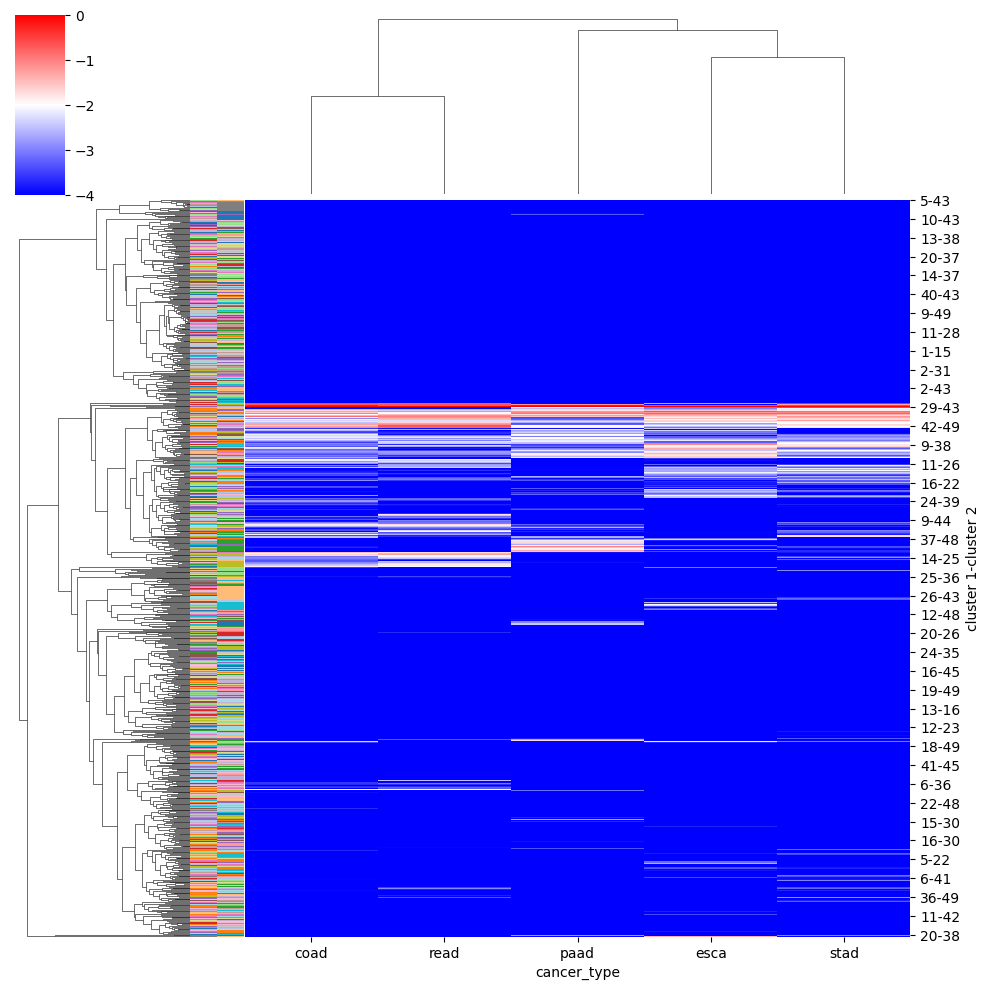

In [103]:
cm = sns.clustermap(np.log2(freq_df+ 0.0001), row_colors = [color1,color2],cmap = 'bwr', vmin = -4, vmax = 0)

In [104]:
clust_colors = [pal[i] for i in fcluster(cm.dendrogram_row.linkage, t = 20, criterion = 'maxclust')]

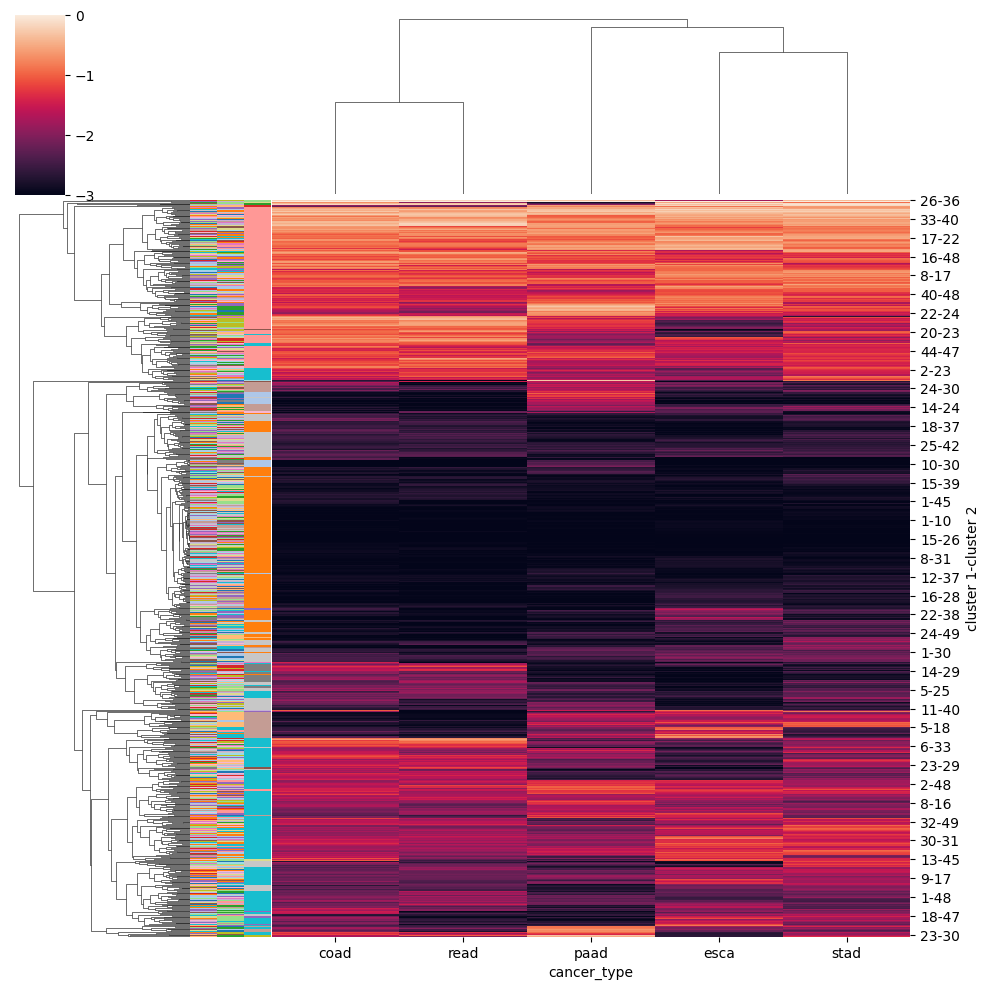

In [109]:
sns.clustermap(np.log10(freq_df+ 0.001), row_colors = [color1,color2, clust_colors])

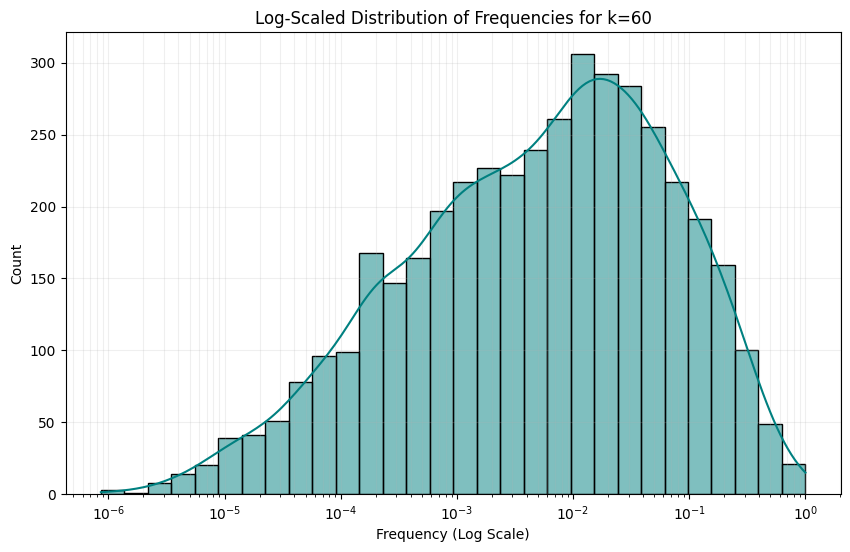

In [106]:

plt.figure(figsize=(10, 6))
# log_scale=True automatically calculates logarithmic bins
sns.histplot(data=filtered_df, x='frequency', log_scale=True, kde=True, color='teal')

plt.title('Log-Scaled Distribution of Frequencies for k=60')
plt.xlabel('Frequency (Log Scale)')
plt.ylabel('Count')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()